# 04 — Regression & Classification

**Quick decision guide — which model do you need?**

| Question type | Target `t` or `y` | Model | Section |
|---|---|---|---|
| Predict a continuous value | Real number (e.g. price, score) | Linear / Polynomial Regression | 1–3 |
| Predict yes/no, 0/1 | Binary (0 or 1) | Logistic Regression | 4–5 |
| Binary + non-linear boundary | Binary + features are polynomial | Regularized Logistic Regression | 6 |

**Normal Equation vs Gradient Descent:**
- Normal Equation = one-shot exact solution. No learning rate, no epochs. Use for regression.
- Gradient Descent = iterative. Required for logistic regression (no closed form).

In [22]:
import numpy as np
import matplotlib.pyplot as plt

---
## 1. Linear Regression (1 variable) — Normal Equation

**When:** predict a continuous `t` from one feature `x`.

Design matrix `Phi` has rows `[1, x]`.
Normal Equation: `W = inv(Phi.T @ Phi) @ Phi.T @ t`

X_bias shape: (50, 2)
First row: [1. 0.]
Weights W: [4.5391 2.5765]
RMSE: 3.1378


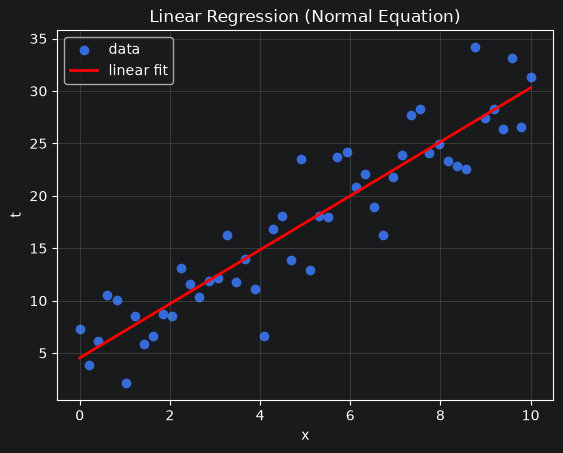

In [23]:
# --- dummy data ---
np.random.seed(0)
x_train = np.linspace(0, 10, 50)
t_train = 3*x_train + 2 + np.random.randn(50)*3
# ------------------

m = x_train.shape[0]

# Design matrix: each row = [1, x]
X_bias = np.column_stack([np.ones(m), x_train])   # shape (m, 2)
print('X_bias shape:', X_bias.shape)                  # (50, 2)
print('First row:', X_bias[0])                     # [1, x[0]]

# Normal equation
W = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ t_train   #Moore-penrose pseudo-inverse (Gives EXACT optimal W in a single iteration)
#OR
moore_penrose = np.linalg.pinv(X_bias)  #Moore-penrose pseudo-inverse (Gives W)
W = np.matmul(moore_penrose, t_train)
print('Weights W:', W.round(4))                 # [intercept, slope]

t_pred = X_bias @ W
rmse   = np.sqrt(np.mean((t_train - t_pred)**2))
print(f'RMSE: {rmse:.4f}')

plt.scatter(x_train, t_train, label='data')
plt.plot(x_train, t_pred, 'r-', linewidth=2, label='linear fit')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Linear Regression (Normal Equation)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 2. Polynomial Regression — Normal Equation

**When:** the scatter plot shows a curve (not a straight line).

Design matrix `Phi` has rows `[1, x, x², ..., x^d]`.
Same Normal Equation formula — just `Phi` has more columns.

**How to pick degree:** look at scatter plot.  
- One bend → degree 2  
- Two bends → degree 3

In [24]:
# --- dummy quadratic data ---
x_train = np.linspace(-3, 3, 50)
t_train = 2*x_train**2 - x_train + 1 + np.random.randn(50)*2
m = x_train.shape[0]
# ----------------------------

DEGREE = 2   # <-- change based on the scatter plot

def build_design_matrix(x, degree):
    # Input:  x shape (m,)
    # Output: Phi shape (m, degree+1)
    # Row i = [1, x[i], x[i]^2, ..., x[i]^degree]
    return np.column_stack([x**i for i in range(degree + 1)])

Phi_train = build_design_matrix(x_train, DEGREE)     # shape (50, 3)
print('Phi_train shape:', Phi_train.shape)
print('First row:', Phi_train[0].round(4))           # [1, x, x²]

Phi_train shape: (50, 3)
First row: [ 1. -3.  9.]


In [25]:
# Normal equation — same formula regardless of degree
W = np.linalg.inv(Phi_train.T @ Phi_train) @ Phi_train.T @ t_train
print('Weights W:', W.round(4))
# W[0] = intercept (w0)
# W[1] = linear coeff (w1)
# W[2] = quadratic coeff (w2)

Weights W: [ 0.6928 -0.6053  2.085 ]


RMSE (expected uncertainty): ±1.5699


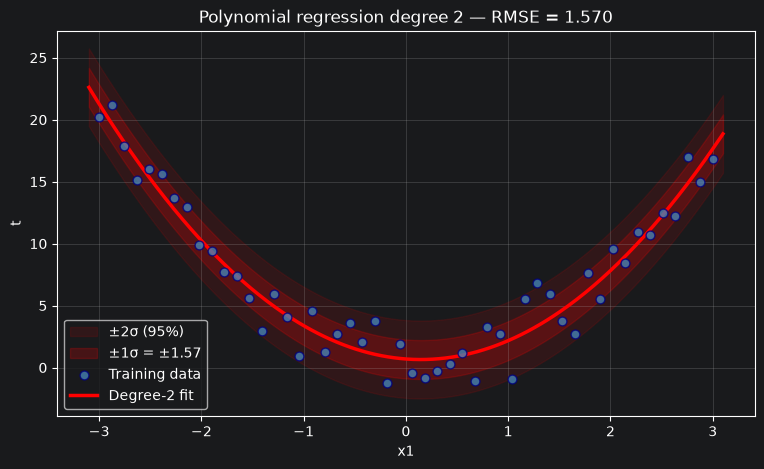

In [26]:
# Predictions and RMSE
t_pred_train = Phi_train @ W
residuals    = t_train - t_pred_train
sigma_pred   = np.sqrt(np.mean(residuals**2))   # RMSE = expected uncertainty

print(f'RMSE (expected uncertainty): ±{sigma_pred:.4f}')

# Plot fit + uncertainty band
x_line  = np.linspace(x_train.min() - 0.1, x_train.max() + 0.1, 300)
t_line  = build_design_matrix(x_line, DEGREE) @ W

plt.figure(figsize=(9, 5))
plt.fill_between(x_line, t_line - 2*sigma_pred, t_line + 2*sigma_pred,
                 alpha=0.1, color='red', label=f'±2σ (95%)')
plt.fill_between(x_line, t_line - sigma_pred, t_line + sigma_pred,
                 alpha=0.2, color='red', label=f'±1σ = ±{sigma_pred:.2f}')
plt.scatter(x_train, t_train, color='steelblue', edgecolors='navy',
            s=40, alpha=0.8, zorder=5, label='Training data')
plt.plot(x_line, t_line, 'r-', linewidth=2.5, zorder=4, label=f'Degree-{DEGREE} fit')
plt.xlabel('x1')
plt.ylabel('t')
plt.title(f'Polynomial regression degree {DEGREE} — RMSE = {sigma_pred:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 3. Multivariate Linear Regression — Normal Equation

**When:** predict `t` from multiple features (e.g. x0, x1, x2). No PCA applied.

Same Normal Equation, `Phi` is `[1, x0, x1, x2, ...]` — just more columns.

In [27]:
# --- dummy multivariate data ---
X_mv = np.random.randn(50, 3)   # 3 features
true_w = np.array([1, 2, -1, 0.5])
t_mv = np.column_stack([np.ones(50), X_mv]) @ true_w + np.random.randn(50)*0.3
m = X_mv.shape[0]
# --------------------------------

# normalize features
mu_mv    = X_mv.mean(axis=0)
sigma_mv = X_mv.std(axis=0)
X_mv_norm = (X_mv - mu_mv) / sigma_mv

# add bias column
Phi_mv = np.hstack([np.ones((m, 1)), X_mv_norm])   # shape (m, 4)
print('Phi_mv shape:', Phi_mv.shape)

# Normal Equation
W_mv = np.linalg.inv(Phi_mv.T @ Phi_mv) @ Phi_mv.T @ t_mv
print('Weights W_mv:', W_mv.round(4))

t_mv_pred = Phi_mv @ W_mv
rmse_mv   = np.sqrt(np.mean((t_mv - t_mv_pred)**2))
print(f'RMSE: {rmse_mv:.4f}')

Phi_mv shape: (50, 4)
Weights W_mv: [ 1.2458  1.8281 -0.9412  0.4611]
RMSE: 0.2947


---
## 4. Logistic Regression — Gradient Descent

**When:** classify into 0 or 1 (binary label). Data is linearly separable.

**Key ideas:**
- Hypothesis: `h = sigmoid(X @ w)`  where `sigmoid(z) = 1 / (1 + exp(-z))`
- Output is a probability: `h >= 0.5` → predict class 1
- Cost function: log-loss (not MSE, because sigmoid makes MSE non-convex)
- Gradient descent updates weights iteratively

In [28]:
# --- dummy classification data (linearly separable) ---
np.random.seed(1)
X_cls = np.random.randn(100, 2)
Y_cls = (X_cls[:, 0] + X_cls[:, 1] > 0).astype(float).reshape(-1, 1)
m_cls, n_cls = X_cls.shape
# ------------------------------------------------------

# normalize
mu_cls    = X_cls.mean(axis=0)
std_cls   = X_cls.std(axis=0)
X_norm_cls = (X_cls - mu_cls) / std_cls

# add bias
X_b = np.hstack([np.ones((m_cls, 1)), X_norm_cls])   # shape (m, 3)
print('X with bias:', X_b.shape)

X with bias: (100, 3)


In [29]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def costFunction(w, X, Y):
    m = Y.size
    h    = sigmoid(X @ w)                               # hypothesis → probabilities
    C    = (-1/m) * np.sum(Y*np.log(h) + (1-Y)*np.log(1-h))  # log-loss
    grad = (1/m) * (X.T @ (h - Y))                     # gradient
    return C, grad

# test with zero weights
w_init = np.zeros((n_cls + 1, 1))   # (3, 1) for 2 features + bias
C, grad = costFunction(w_init, X_b, Y_cls)
print(f'Cost at zero weights (should be ~0.693): {C:.4f}')

Cost at zero weights (should be ~0.693): 0.6931


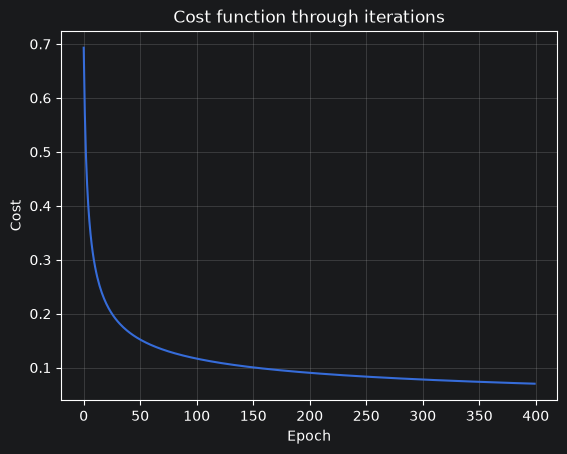

Final cost: 0.0702


In [30]:
def gradientDescent(X, Y, w, learning_rate, epochs):
    C_history = []
    for i in range(epochs):
        C, grad = costFunction(w, X, Y)
        w = w - learning_rate * grad
        C_history.append(C)
    return w, np.array(C_history)

w_lr  = 1
epochs = 400
w_cls, C_hist = gradientDescent(X_b, Y_cls, np.zeros((n_cls+1, 1)), w_lr, epochs)

plt.plot(C_hist)
plt.title('Cost function through iterations')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.grid(True, alpha=0.3)
plt.show()
print('Final cost:', C_hist[-1].round(4))

In [31]:
# Accuracy
predictions = (sigmoid(X_b @ w_cls) >= 0.5)   # True/False
accuracy    = (np.sum(predictions == Y_cls) / m_cls) * 100
print(f'Accuracy: {accuracy:.1f}%')

Accuracy: 100.0%


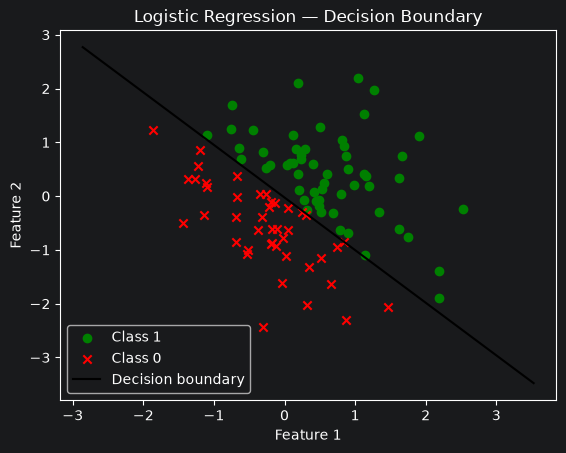

In [32]:
# Decision boundary plot (linear case)
pos = X_cls[Y_cls.flatten() == 1]
neg = X_cls[Y_cls.flatten() == 0]

x1_range = np.array([X_cls[:, 0].min() - 1, X_cls[:, 0].max() + 1])
x1_norm  = (x1_range - mu_cls[0]) / std_cls[0]
x2_norm  = (-w_cls[0] - w_cls[1]*x1_norm) / w_cls[2]
x2_range = x2_norm * std_cls[1] + mu_cls[1]

plt.scatter(pos[:, 0], pos[:, 1], c='g', marker='o', label='Class 1')
plt.scatter(neg[:, 0], neg[:, 1], c='r', marker='x', label='Class 0')
plt.plot(x1_range, x2_range, 'k-', label='Decision boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression — Decision Boundary')
plt.legend()
plt.show()

---
## 5. Predict a single new sample (Logistic Regression)

In [33]:
def predict_logistic(x_new, w, mean, std):
    # x_new = raw feature vector, e.g. np.array([45, 85])
    x_norm = (x_new - mean) / std           # normalize with training stats
    x_bias = np.append(1, x_norm)           # add bias → [1, x1_norm, x2_norm]
    h      = sigmoid(x_bias @ w).item()     # probability (scalar)
    pred   = 1 if h >= 0.5 else 0
    return pred, h

sample = np.array([0.5, 0.5])
pred, prob = predict_logistic(sample, w_cls, mu_cls, std_cls)
print(f'Predicted class: {pred}  |  Probability: {prob:.4f}')

Predicted class: 1  |  Probability: 0.9992


---
## 6. Regularized Logistic Regression (non-linear boundary)

**When:** data is not linearly separable. You expand features polynomially, then add a regularization term (lambda) to the cost to prevent overfitting.

**Key difference from plain logistic regression:**
- Features are expanded: `[1, x1, x2, x1², x1*x2, x2², ...]` using `mapFeature`
- Cost has extra penalty term: `+ (lambda / 2m) * sum(w[1:]²)` — bias `w[0]` NOT penalized
- Gradient has extra term for all weights except bias

In [34]:
def mapFeature(X1, X2, deg):
    # Polynomial feature expansion up to degree `deg`
    # For two input features, builds all cross-terms
    # E.g. deg=3 → [1, x1, x2, x1², x1*x2, x2², x1³, x1²x2, x1x2², x2³] = 10 features
    X1 = np.atleast_1d(np.asarray(X1, dtype=float))
    X2 = np.atleast_1d(np.asarray(X2, dtype=float))
    m  = X1.shape[0]
    out = np.ones((m, 1))
    for i in range(1, deg + 1):
        for j in range(i + 1):
            term = ((X1**(i-j)) * (X2**j)).reshape(m, 1)
            out  = np.hstack((out, term))
    return out

In [35]:
# --- dummy non-linearly separable data ---
np.random.seed(5)
theta = np.linspace(0, 2*np.pi, 60)
r_pos = 0.5 + np.random.randn(60)*0.1
r_neg = 1.0 + np.random.randn(60)*0.1
X_nl = np.vstack([
    np.column_stack([r_pos*np.cos(theta), r_pos*np.sin(theta)]),
    np.column_stack([r_neg*np.cos(theta), r_neg*np.sin(theta)])
])
Y_nl = np.vstack([np.ones((60,1)), np.zeros((60,1))])
m_nl = X_nl.shape[0]
# -----------------------------------------

deg = 3
X_nl_exp = mapFeature(X_nl[:, 0], X_nl[:, 1], deg)   # shape (m, 10)
print('Expanded features shape:', X_nl_exp.shape)

Expanded features shape: (120, 10)


In [36]:
def costFunctionReg(w, X, Y, Lambda=1):
    m = Y.size
    h    = sigmoid(X @ w)
    C    = (-1/m) * np.sum(Y*np.log(h) + (1-Y)*np.log(1-h))
    C   += (Lambda / (2*m)) * np.sum(w[1:]**2)       # penalize all weights EXCEPT bias w[0]
    grad = (1/m) * (X.T @ (h - Y))
    grad[1:] += (Lambda / m) * w[1:]                 # regularize gradient (skip bias)
    return C, grad

def gradientDescentReg(X, Y, w, learning_rate, epochs, Lambda):
    C_history = []
    for i in range(epochs):
        C, grad = costFunctionReg(w, X, Y, Lambda)
        w = w - learning_rate * grad
        C_history.append(C)
    return w, np.array(C_history)

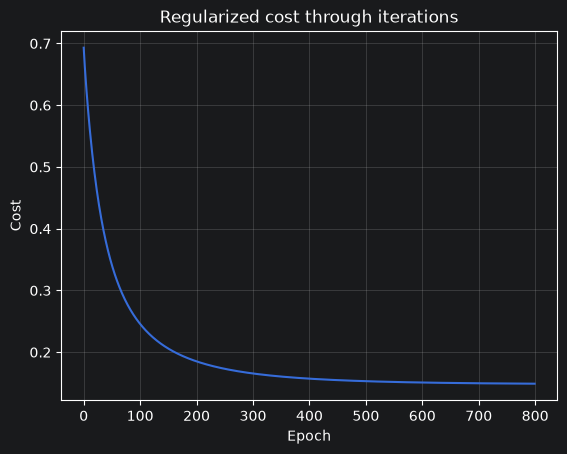

Final cost: 0.149
Accuracy: 98.3%


In [37]:
Lambda = 0.1      # regularization strength
lr     = 1.0      # learning rate
epochs = 800

w_nl_init = np.zeros((X_nl_exp.shape[1], 1))
w_nl, C_hist_nl = gradientDescentReg(X_nl_exp, Y_nl, w_nl_init, lr, epochs, Lambda)

plt.plot(C_hist_nl)
plt.title('Regularized cost through iterations')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.grid(True, alpha=0.3)
plt.show()
print('Final cost:', C_hist_nl[-1].round(4))

acc_nl = (np.sum((sigmoid(X_nl_exp @ w_nl) >= 0.5) == Y_nl) / m_nl) * 100
print(f'Accuracy: {acc_nl:.1f}%')

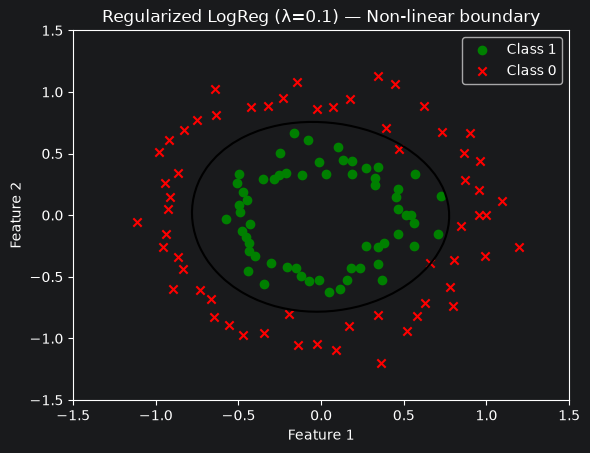

In [38]:
# Non-linear decision boundary via contour plot
pos_nl = X_nl[Y_nl.flatten() == 1]
neg_nl = X_nl[Y_nl.flatten() == 0]

u_vals = np.linspace(-1.5, 1.5, 60)
v_vals = np.linspace(-1.5, 1.5, 60)
z_nl   = np.zeros((len(u_vals), len(v_vals)))

for i in range(len(u_vals)):
    for j in range(len(v_vals)):
        z_nl[i, j] = (mapFeature(u_vals[i], v_vals[j], deg) @ w_nl)[0, 0]

plt.scatter(pos_nl[:, 0], pos_nl[:, 1], c='g', marker='o', label='Class 1')
plt.scatter(neg_nl[:, 0], neg_nl[:, 1], c='r', marker='x', label='Class 0')
plt.contour(u_vals, v_vals, z_nl.T, levels=[0], colors='black')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Regularized LogReg (λ={Lambda}) — Non-linear boundary')
plt.legend()
plt.show()

---
## Summary — which functions to copy into the exam

### Regression (Normal Equation)
```python
def build_design_matrix(x, degree):
    return np.column_stack([x**i for i in range(degree + 1)])

Phi = build_design_matrix(x_train, DEGREE)           # (m, degree+1)
W   = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ t_train  # normal equation
t_pred  = Phi @ W
sigma   = np.sqrt(np.mean((t_train - t_pred)**2))    # RMSE = uncertainty
```

### Logistic Regression
```python
def sigmoid(z):   return 1 / (1 + np.exp(-z))

def costFunction(w, X, Y):
    m    = Y.size
    h    = sigmoid(X @ w)
    C    = (-1/m) * np.sum(Y*np.log(h) + (1-Y)*np.log(1-h))
    grad = (1/m) * (X.T @ (h - Y))
    return C, grad

def gradientDescent(X, Y, w, lr, epochs):
    C_history = []
    for i in range(epochs):
        C, grad = costFunction(w, X, Y)
        w = w - lr * grad
        C_history.append(C)
    return w, np.array(C_history)
```

### Regularized Logistic Regression
```python
def costFunctionReg(w, X, Y, Lambda=1):
    m    = Y.size
    h    = sigmoid(X @ w)
    C    = (-1/m) * np.sum(Y*np.log(h) + (1-Y)*np.log(1-h))
    C   += (Lambda/(2*m)) * np.sum(w[1:]**2)    # no penalty on bias w[0]
    grad = (1/m) * (X.T @ (h - Y))
    grad[1:] += (Lambda/m) * w[1:]
    return C, grad
```

### Lambda effect:
- `Lambda = 0` → no regularization (may overfit)
- `Lambda` very large → underfits (model too simple)
- Good range to try: `0.01, 0.1, 1, 10`